Hypothesis:

As information diffuses more rapidly in modern financial markets, the optimal momentum formation period has gradually shortened.

monthly_close shape: (132, 502)
monthly_ret shape: (132, 502)
monthly_close index head: DatetimeIndex(['2015-01-31', '2015-02-28', '2015-03-31', '2015-04-30',
               '2015-05-31'],
              dtype='datetime64[ns]', name='Date', freq='ME')
monthly_ret index head: DatetimeIndex(['2015-01-31', '2015-02-28', '2015-03-31', '2015-04-30',
               '2015-05-31'],
              dtype='datetime64[ns]', name='Date', freq='ME')

Rolling summary head:


,window_start,window_end,best_J,best_mean_monthly_ls,best_nw_tstat,best_n_obs
0,2015-01-31,2019-12-31,9,-0.000320,-0.066605,50
1,2015-07-31,2020-06-30,9,0.004194,1.047281,50
2,2016-01-31,2020-12-31,9,0.003810,0.706900,50
3,2016-07-31,2021-06-30,6,0.003988,0.983060,53
4,2017-01-31,2021-12-31,3,0.003449,0.935455,56



Rolling returns head:


,window_start,window_end,J,K,mean_monthly_ls,nw_tstat_mean_ls,n_obs
0,2015-01-31,2019-12-31,3,3,-0.002053,-0.542763,56
1,2015-01-31,2019-12-31,6,3,-0.001422,-0.321568,53
2,2015-01-31,2019-12-31,9,3,-0.000320,-0.066605,50
3,2015-01-31,2019-12-31,12,3,-0.005138,-0.868122,47
4,2015-07-31,2020-06-30,3,3,-0.001890,-0.490742,56
5,2015-07-31,2020-06-30,6,3,-0.001659,-0.347719,53
6,2015-07-31,2020-06-30,9,3,0.004194,1.047281,50
7,2015-07-31,2020-06-30,12,3,0.000612,0.131594,47
8,2016-01-31,2020-12-31,3,3,0.000923,0.269878,56
9,2016-01-31,2020-12-31,6,3,0.002332,0.551884,53



Mean return pivot:


J,3,6,9,12
window_end,,,,
2019-12-31,-0.0021,-0.0014,-0.0003,-0.0051
2020-06-30,-0.0019,-0.0017,0.0042,0.0006
2020-12-31,0.0009,0.0023,0.0038,0.0025
2021-06-30,0.0032,0.0040,0.0016,-0.0022
2021-12-31,0.0034,0.0026,-0.0013,-0.0036
2022-06-30,0.0048,0.0040,0.0016,-0.0002
2022-12-31,0.0039,0.0049,0.0022,0.0022
2023-06-30,0.0018,0.0030,-0.0007,-0.0053
2023-12-31,0.0005,0.0022,-0.0029,-0.0047



T-stat pivot:


J,3,6,9,12
window_end,,,,
2019-12-31,-0.54,-0.32,-0.07,-0.87
2020-06-30,-0.49,-0.35,1.05,0.13
2020-12-31,0.27,0.55,0.71,0.49
2021-06-30,0.87,0.98,0.29,-0.31
2021-12-31,0.94,0.64,-0.22,-0.52
2022-06-30,1.07,0.81,0.27,-0.02
2022-12-31,0.95,1.00,0.37,0.29
2023-06-30,0.38,0.70,-0.11,-0.64
2023-12-31,0.10,0.51,-0.46,-0.55



Trend regression: best_J ~ time_index
                            OLS Regression Results                            
Dep. Variable:                 best_J   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                 -0.037
Method:                 Least Squares   F-statistic:                    0.5741
Date:                Sat, 27 Jun 2026   Prob (F-statistic):              0.465
Time:                        20:18:11   Log-Likelihood:                -31.357
No. Observations:                  13   AIC:                             66.71
Df Residuals:                      11   BIC:                             67.84
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        

/opt/miniconda3/envs/quant/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=13 observations were given.
  return hypotest_fun_in(*args, **kwds)


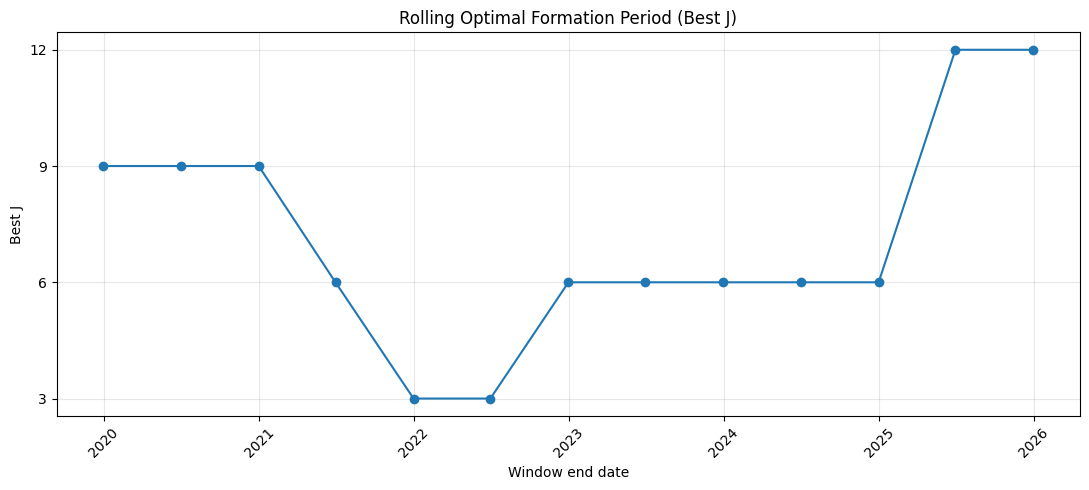

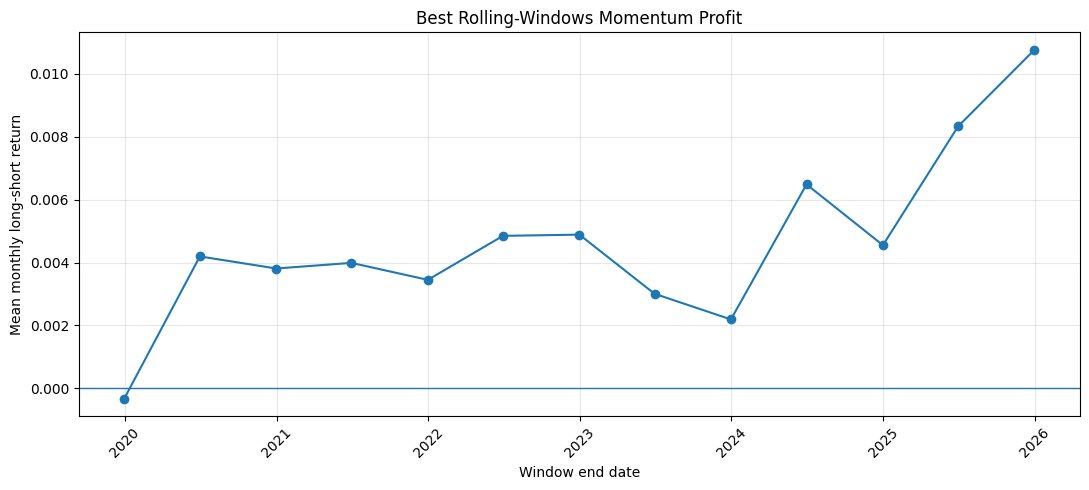

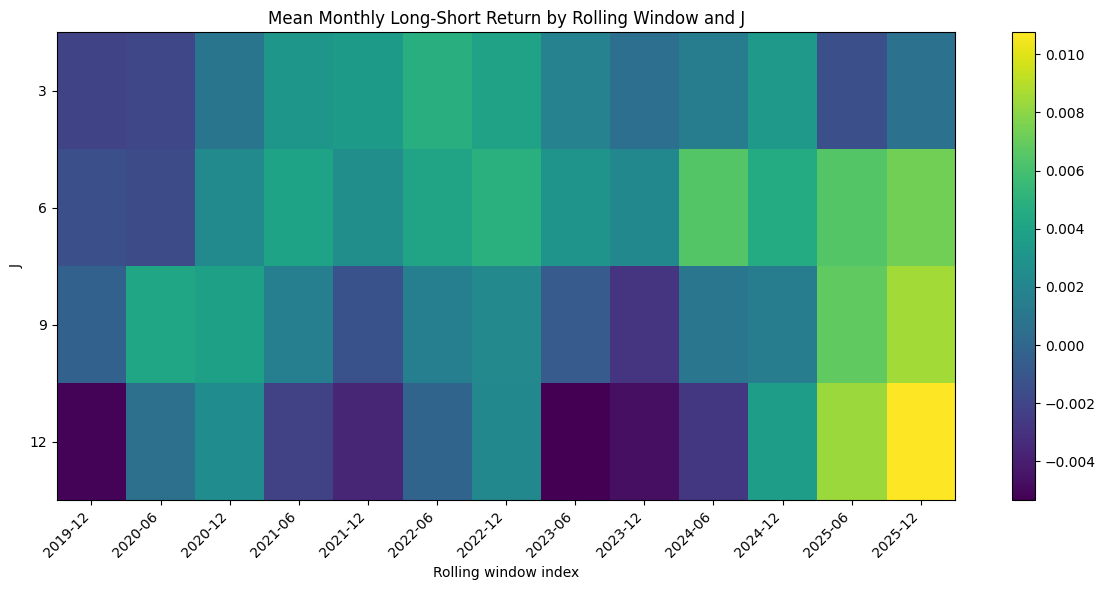


How often each J is optimal:


,count
best_J,
3,2
6,6
9,3
12,2



Rolling summary (selected columns):


,window_start,window_end,best_J,best_mean_monthly_ls,best_nw_tstat
0,2015-01-31,2019-12-31,9,-0.0003,-0.0666
1,2015-07-31,2020-06-30,9,0.0042,1.0473
2,2016-01-31,2020-12-31,9,0.0038,0.7069
3,2016-07-31,2021-06-30,6,0.0040,0.9831
4,2017-01-31,2021-12-31,3,0.0034,0.9355
5,2017-07-31,2022-06-30,3,0.0048,1.0655
6,2018-01-31,2022-12-31,6,0.0049,0.9959
7,2018-07-31,2023-06-30,6,0.0030,0.7019
8,2019-01-31,2023-12-31,6,0.0022,0.5099
9,2019-07-31,2024-06-30,6,0.0065,1.4225



Saved outputs to ../results/


In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# Extension: Does the optimal momentum formation period shorten over time?
# Rolling-window analysis on modern S&P 500 data
# ============================================================

# ----------------------------
# 1) Load data
# ----------------------------
prices = pd.read_parquet("../data/sp500_prices.parquet")

daily_close = prices["Close"].copy().sort_index()
daily_close = daily_close.dropna(axis=1, how="all")

monthly_close = daily_close.resample("ME").last()
monthly_close = monthly_close.dropna(axis=1, how="all")

monthly_ret = monthly_close.pct_change(fill_method=None)

print("monthly_close shape:", monthly_close.shape)
print("monthly_ret shape:", monthly_ret.shape)
print("monthly_close index head:", monthly_close.index[:5])
print("monthly_ret index head:", monthly_ret.index[:5])

# Equal-weighted market proxy (not required for the main extension,
# but useful to keep in the notebook if you want to compare later)
market_ret = monthly_ret.mean(axis=1, skipna=True).rename("market_ret")


# ----------------------------
# 2) Helper functions
# ----------------------------
def compute_formation_signal(monthly_close: pd.DataFrame, J: int = 6) -> pd.DataFrame:
    """
    Past J-month cumulative return used for ranking.
    signal[t] = P_t / P_{t-J} - 1
    """
    return monthly_close.pct_change(periods=J, fill_method=None)


def assign_deciles(signal_row: pd.Series, n_deciles: int = 10) -> pd.Series:
    """
    1 = losers decile
    10 = winners decile
    """
    x = signal_row.dropna()
    if len(x) < n_deciles:
        return pd.Series(dtype="int64")

    # rank(method="first") avoids qcut failures when there are many ties
    ranks = x.rank(method="first")
    labels = pd.qcut(ranks, n_deciles, labels=False) + 1
    return pd.Series(labels.astype(int), index=x.index)


def momentum_backtest(
    monthly_close: pd.DataFrame,
    monthly_ret: pd.DataFrame,
    J: int = 6,
    K: int = 3,
    n_deciles: int = 10,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Overlapping momentum backtest.

    For each formation month:
    - rank stocks by past J-month cumulative return
    - winners = top decile
    - losers  = bottom decile
    - hold each subportfolio for K months
    - at each calendar month, average across all active subportfolios

    Returns
    -------
    strategy_df : monthly winner / loser / long-short returns
    holdings_df : formation-date holdings
    """
    signal = compute_formation_signal(monthly_close, J=J)
    dates = monthly_close.index

    subportfolios = []
    holdings_rows = []

    for formation_pos, dt in enumerate(dates):
        if dt not in signal.index:
            continue

        row = signal.loc[dt]
        deciles = assign_deciles(row, n_deciles=n_deciles)
        if deciles.empty:
            continue

        winners = deciles[deciles == n_deciles].index.tolist()
        losers = deciles[deciles == 1].index.tolist()

        start_pos = formation_pos + 1
        end_pos = min(formation_pos + K, len(dates) - 1)
        if start_pos >= len(dates):
            continue

        subportfolios.append(
            {
                "formation_date": dt,
                "start_pos": start_pos,
                "end_pos": end_pos,
                "winners": winners,
                "losers": losers,
                "J": J,
                "K": K,
            }
        )

        holdings_rows.append(
            {
                "formation_date": dt,
                "n_winners": len(winners),
                "n_losers": len(losers),
                "winners": winners,
                "losers": losers,
                "J": J,
                "K": K,
            }
        )

    out = []
    for t_pos, dt in enumerate(dates):
        active_winner_rets = []
        active_loser_rets = []

        r = monthly_ret.loc[dt]

        for sp in subportfolios:
            if sp["start_pos"] <= t_pos <= sp["end_pos"]:
                w = sp["winners"]
                l = sp["losers"]

                wret = r[w].dropna().mean() if len(w) > 0 else np.nan
                lret = r[l].dropna().mean() if len(l) > 0 else np.nan

                if pd.notna(wret) and pd.notna(lret):
                    active_winner_rets.append(wret)
                    active_loser_rets.append(lret)

        if len(active_winner_rets) == 0:
            continue

        winner_ret = float(np.mean(active_winner_rets))
        loser_ret = float(np.mean(active_loser_rets))
        ls_ret = winner_ret - loser_ret

        out.append(
            {
                "date": dt,
                "winner_ret": winner_ret,
                "loser_ret": loser_ret,
                "long_short_ret": ls_ret,
                "n_active_subportfolios": len(active_winner_rets),
            }
        )

    strategy_df = pd.DataFrame(out).set_index("date").sort_index()
    holdings_df = pd.DataFrame(holdings_rows).set_index("formation_date").sort_index()
    return strategy_df, holdings_df


def nw_mean_tstat(r: pd.Series, maxlags: int = 5) -> tuple[float, float]:
    """
    Newey-West t-stat for the mean return.
    """
    r = r.dropna()
    if len(r) == 0:
        return np.nan, np.nan

    X = np.ones((len(r), 1))
    model = sm.OLS(r.values, X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
    return float(model.params[0]), float(model.tvalues[0])


# ----------------------------
# 3) Rolling-window experiment
# ----------------------------
# You can change these if you want more or fewer windows
window_months = 60   # 5 years
step_months = 6      # move window by 6 months
J_list = [3, 6, 9, 12]
K_fixed = 3

dates = monthly_close.index
window_end_positions = list(range(window_months - 1, len(dates), step_months))

rolling_rows = []
window_return_rows = []

for end_pos in window_end_positions:
    start_pos = end_pos - window_months + 1

    start_date = dates[start_pos]
    end_date = dates[end_pos]

    monthly_close_win = monthly_close.loc[start_date:end_date]
    monthly_ret_win = monthly_ret.loc[start_date:end_date]

    # Skip windows that are too short after data cleaning
    if len(monthly_close_win) < window_months:
        continue

    j_rows = []

    for J in J_list:
        bt, holdings = momentum_backtest(
            monthly_close=monthly_close_win,
            monthly_ret=monthly_ret_win,
            J=J,
            K=K_fixed,
            n_deciles=10,
        )

        if len(bt) == 0:
            mean_ls = np.nan
            tstat_ls = np.nan
            n_obs = 0
        else:
            mean_ls = bt["long_short_ret"].mean()
            _, tstat_ls = nw_mean_tstat(bt["long_short_ret"], maxlags=5)
            n_obs = len(bt)

        j_rows.append(
            {
                "window_start": start_date,
                "window_end": end_date,
                "J": J,
                "K": K_fixed,
                "mean_monthly_ls": mean_ls,
                "nw_tstat_mean_ls": tstat_ls,
                "n_obs": n_obs,
            }
        )

    window_df = pd.DataFrame(j_rows)

    # Best J by mean monthly long-short return in this rolling window
    best_row = window_df.loc[window_df["mean_monthly_ls"].idxmax()] if window_df["mean_monthly_ls"].notna().any() else None

    if best_row is not None:
        rolling_rows.append(
            {
                "window_start": start_date,
                "window_end": end_date,
                "best_J": int(best_row["J"]),
                "best_mean_monthly_ls": float(best_row["mean_monthly_ls"]),
                "best_nw_tstat": float(best_row["nw_tstat_mean_ls"]),
                "best_n_obs": int(best_row["n_obs"]),
            }
        )

    window_return_rows.extend(j_rows)

rolling_summary = pd.DataFrame(rolling_rows).sort_values("window_end").reset_index(drop=True)
window_returns = pd.DataFrame(window_return_rows).sort_values(["window_end", "J"]).reset_index(drop=True)

print("\nRolling summary head:")
display(rolling_summary.head())

print("\nRolling returns head:")
display(window_returns.head(12))

# ----------------------------
# 4) Pivot tables for visualization
# ----------------------------
mean_return_pivot = window_returns.pivot(index="window_end", columns="J", values="mean_monthly_ls")
tstat_pivot = window_returns.pivot(index="window_end", columns="J", values="nw_tstat_mean_ls")

print("\nMean return pivot:")
display(mean_return_pivot.round(4))

print("\nT-stat pivot:")
display(tstat_pivot.round(2))

# ----------------------------
# 5) Trend diagnostics
# ----------------------------
# Convert window end date to a numeric time index for a simple trend regression
trend_df = rolling_summary.dropna(subset=["best_J"]).copy()
trend_df["time_index"] = np.arange(len(trend_df))

if len(trend_df) >= 3:
    X = sm.add_constant(trend_df["time_index"])
    y = trend_df["best_J"].astype(float)
    trend_model = sm.OLS(y, X).fit()

    print("\nTrend regression: best_J ~ time_index")
    print(trend_model.summary())

    slope = trend_model.params["time_index"]
    t_slope = trend_model.tvalues["time_index"]
    p_slope = trend_model.pvalues["time_index"]
else:
    slope = np.nan
    t_slope = np.nan
    p_slope = np.nan

print("\nTrend diagnostics:")
print(f"slope = {slope:.4f}")
print(f"t-stat = {t_slope:.4f}")
print(f"p-val  = {p_slope:.4f}")

# ----------------------------
# 6) Plots
# ----------------------------
# Plot A: best J through time
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(rolling_summary["window_end"], rolling_summary["best_J"], marker="o")
ax.set_title("Rolling Optimal Formation Period (Best J)")
ax.set_xlabel("Window end date")
ax.set_ylabel("Best J")
ax.set_yticks(J_list)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot B: best monthly long-short return through time
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(rolling_summary["window_end"], rolling_summary["best_mean_monthly_ls"], marker="o")
ax.axhline(0, linewidth=1)
ax.set_title("Best Rolling-Windows Momentum Profit")
ax.set_xlabel("Window end date")
ax.set_ylabel("Mean monthly long-short return")
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot C: heatmap of mean returns by J and window end date
fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(mean_return_pivot.T.values, aspect="auto", interpolation="nearest")
ax.set_title("Mean Monthly Long-Short Return by Rolling Window and J")
ax.set_xlabel("Rolling window index")
ax.set_ylabel("J")
ax.set_yticks(range(len(mean_return_pivot.columns)))
ax.set_yticklabels(mean_return_pivot.columns)

# Show window-end labels sparsely to keep the axis readable
x_ticks = np.arange(mean_return_pivot.shape[0])
if len(x_ticks) > 0:
    step = max(1, len(x_ticks) // 8)
    ax.set_xticks(x_ticks[::step])
    ax.set_xticklabels([mean_return_pivot.index[i].strftime("%Y-%m") for i in x_ticks[::step]], rotation=45, ha="right")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# ----------------------------
# 7) Compact tables
# ----------------------------
best_j_counts = rolling_summary["best_J"].value_counts().sort_index()

print("\nHow often each J is optimal:")
display(best_j_counts.to_frame("count"))

print("\nRolling summary (selected columns):")
display(rolling_summary[["window_start", "window_end", "best_J", "best_mean_monthly_ls", "best_nw_tstat"]].round(4))

# ----------------------------
# 8) Save outputs
# ----------------------------
Path("../results").mkdir(exist_ok=True)

rolling_summary.to_csv("../results/extension_rolling_best_J_summary.csv", index=False)
window_returns.to_csv("../results/extension_rolling_window_returns.csv", index=False)
mean_return_pivot.to_csv("../results/extension_mean_return_pivot.csv")
tstat_pivot.to_csv("../results/extension_tstat_pivot.csv")

print("\nSaved outputs to ../results/")

Rolling-window evidence suggests that the optimal momentum formation horizon is time-varying rather than monotonically declining. While the full-sample modern replication favors a 6/3 strategy, shorter horizons do not dominate uniformly across subperiods. Instead, the best-performing J alternates between 3, 6, 9, and 12 months across different market regimes, indicating that momentum horizons are regime-dependent rather than steadily shortening over time.